**Description**

This notebook performs comprehensive **Exploratory Data Analysis (EDA)** and **data cleaning** on Balancer V1 and V2 LBP datasets to prepare high-quality training data for machine learning models that predict LBP success metrics.

## Key Objectives
1. **Load & Inspect Data**: Import finalized V1 and V2 LBP datasets and examine their structure, data types, and basic statistics
2. **Exploratory Data Analysis**: Visualize distributions, class balance, feature relationships, and identify patterns in successful vs. failed LBPs
3. **Data Quality Assessment**: Detect missing values, outliers, invalid entries (e.g., negative liquidity values)
4. **Feature Engineering**: Create new derived features (e.g., weekend activity percentage) to enhance model inputs
5. **Data Cleaning & Preparation**: Apply transformation and filtering logic to produce clean datasets ready for ML training
6. **Output Generation**: Export cleaned datasets as ML-ready CSV files with selected features and target variables

## Key Analysis Steps
- **Class Balance Analysis**: Check target variable distributions (success metrics)
- **Numerical Feature Distributions**: Histogram plots of all numerical features
- **Feature Separation**: Boxplots comparing features between successful and unsuccessful pools
- **Correlation Analysis**: Identify relationships between features
- **Bot & Configuration Impact**: Analyze how bot volume, weights, and pool parameters affect outcomes
- **Data Validation**: Remove or flag bad data (negative values, invalid dates, etc.)
- **Final ML Dataset Creation**: Select feature columns and target columns, save cleaned datasets

## Outputs
- `v1_df_ml` & `v2_df_ml`: ML-ready datasets with complete features and targets
- `balancer_v1_ml_training_data.csv` & `balancer_v2_ml_training_data.csv`: Exported CSV files for model training


# Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns
import numpy as np

# V1

In [3]:
v1_df = pd.read_csv('../media/v1/FINAL_LBPs_BalancerV1.csv')
v1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   pool_id                      96 non-null     object 
 1   launch_date                  96 non-null     object 
 2   duration_h                   96 non-null     float64
 3   start_weight_proj            96 non-null     float64
 4   end_weight_proj              96 non-null     float64
 5   weight_slope                 96 non-null     float64
 6   total_swaps                  96 non-null     int64  
 7   unique_users                 96 non-null     int64  
 8   swaps_per_hour               96 non-null     float64
 9   peak_activity_time           96 non-null     float64
 10  price_efficiency             96 non-null     float64
 11  max_drawdown                 96 non-null     float64
 12  buy_pressure_avg             96 non-null     float64
 13  is_dead_pool          

## Data distribution and cleaning

--- 1. Checking Class Balance ---


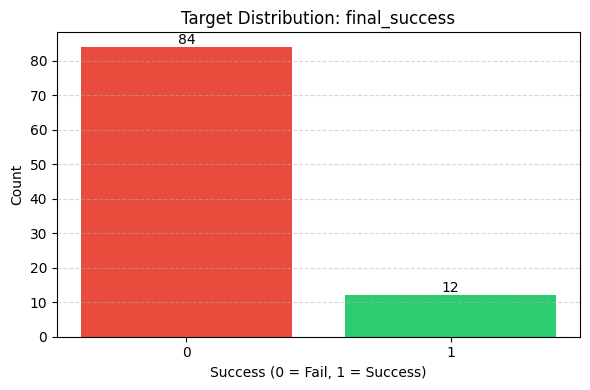

--- 2. Checking Numerical Distributions ---


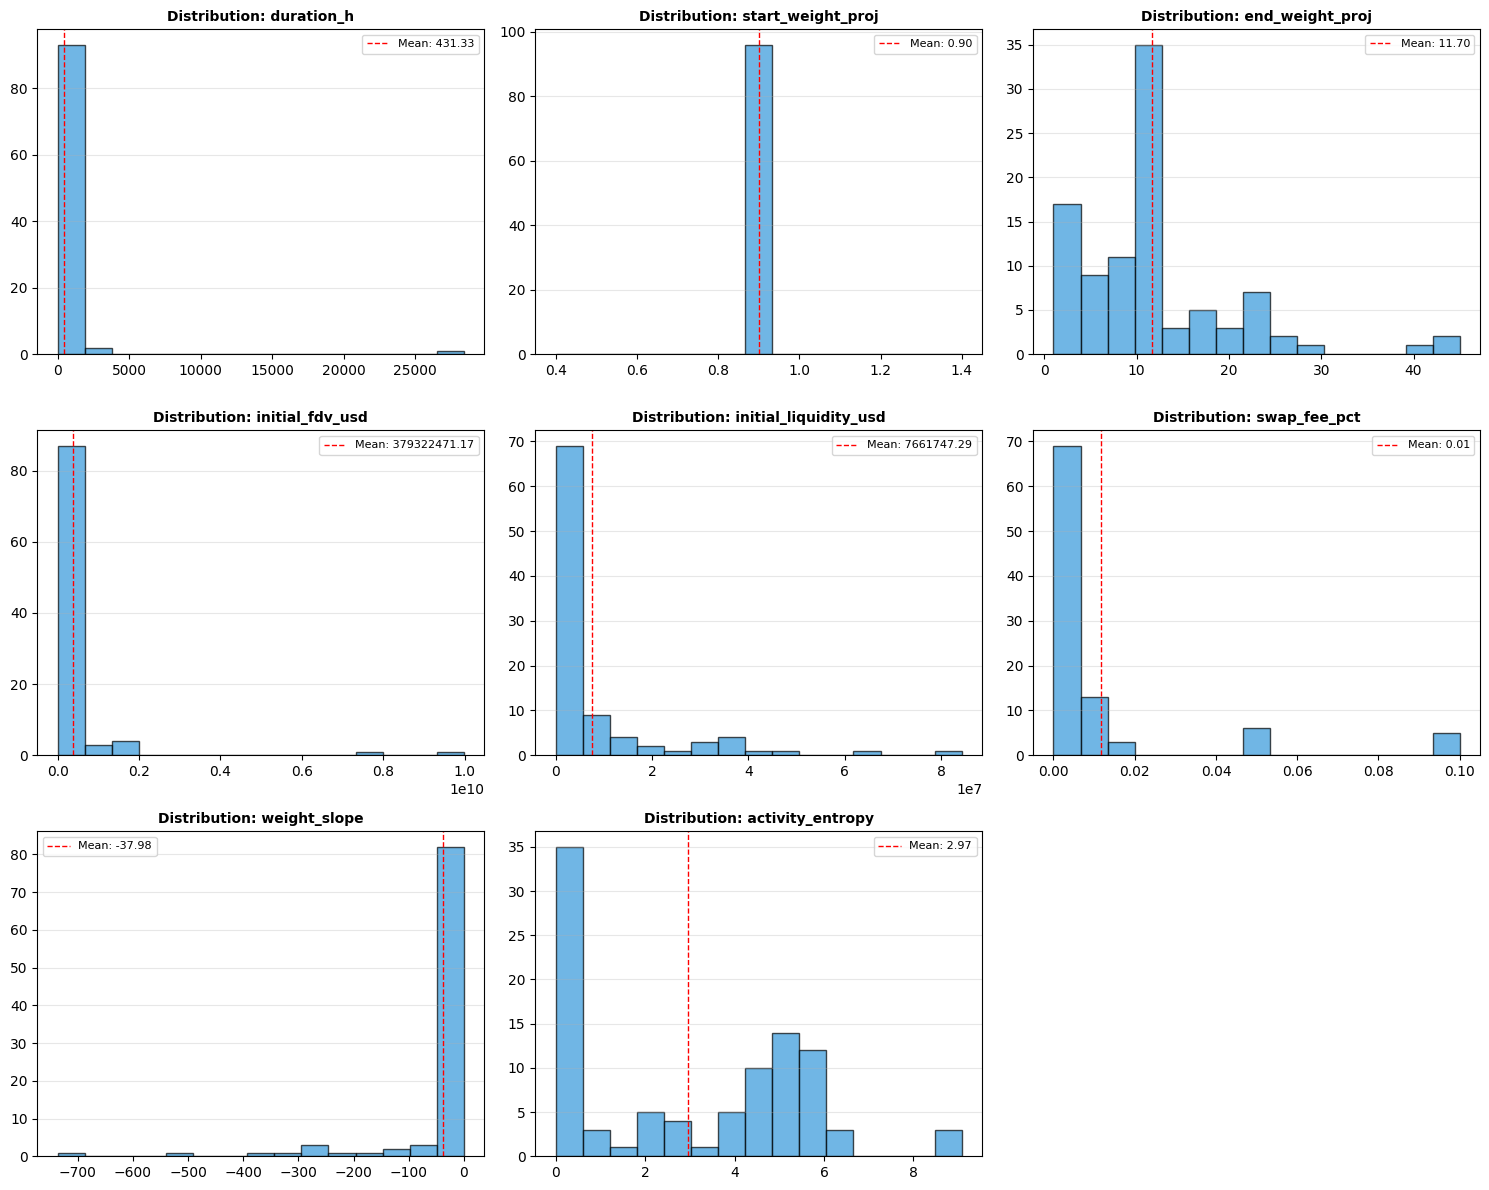

--- 3. Checking Feature Separation (Boxplots) ---


C:\Users\kaiqu\AppData\Local\Temp\ipykernel_21668\3008103398.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1], labels=['Fail (0)', 'Success (1)'],
C:\Users\kaiqu\AppData\Local\Temp\ipykernel_21668\3008103398.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1], labels=['Fail (0)', 'Success (1)'],
C:\Users\kaiqu\AppData\Local\Temp\ipykernel_21668\3008103398.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1], labels=['Fail (0)', 'Success (1)'],
C:\Users\kaiqu\AppData\Local\Temp\ipykernel_21668\3008103398.py:73: Matpl

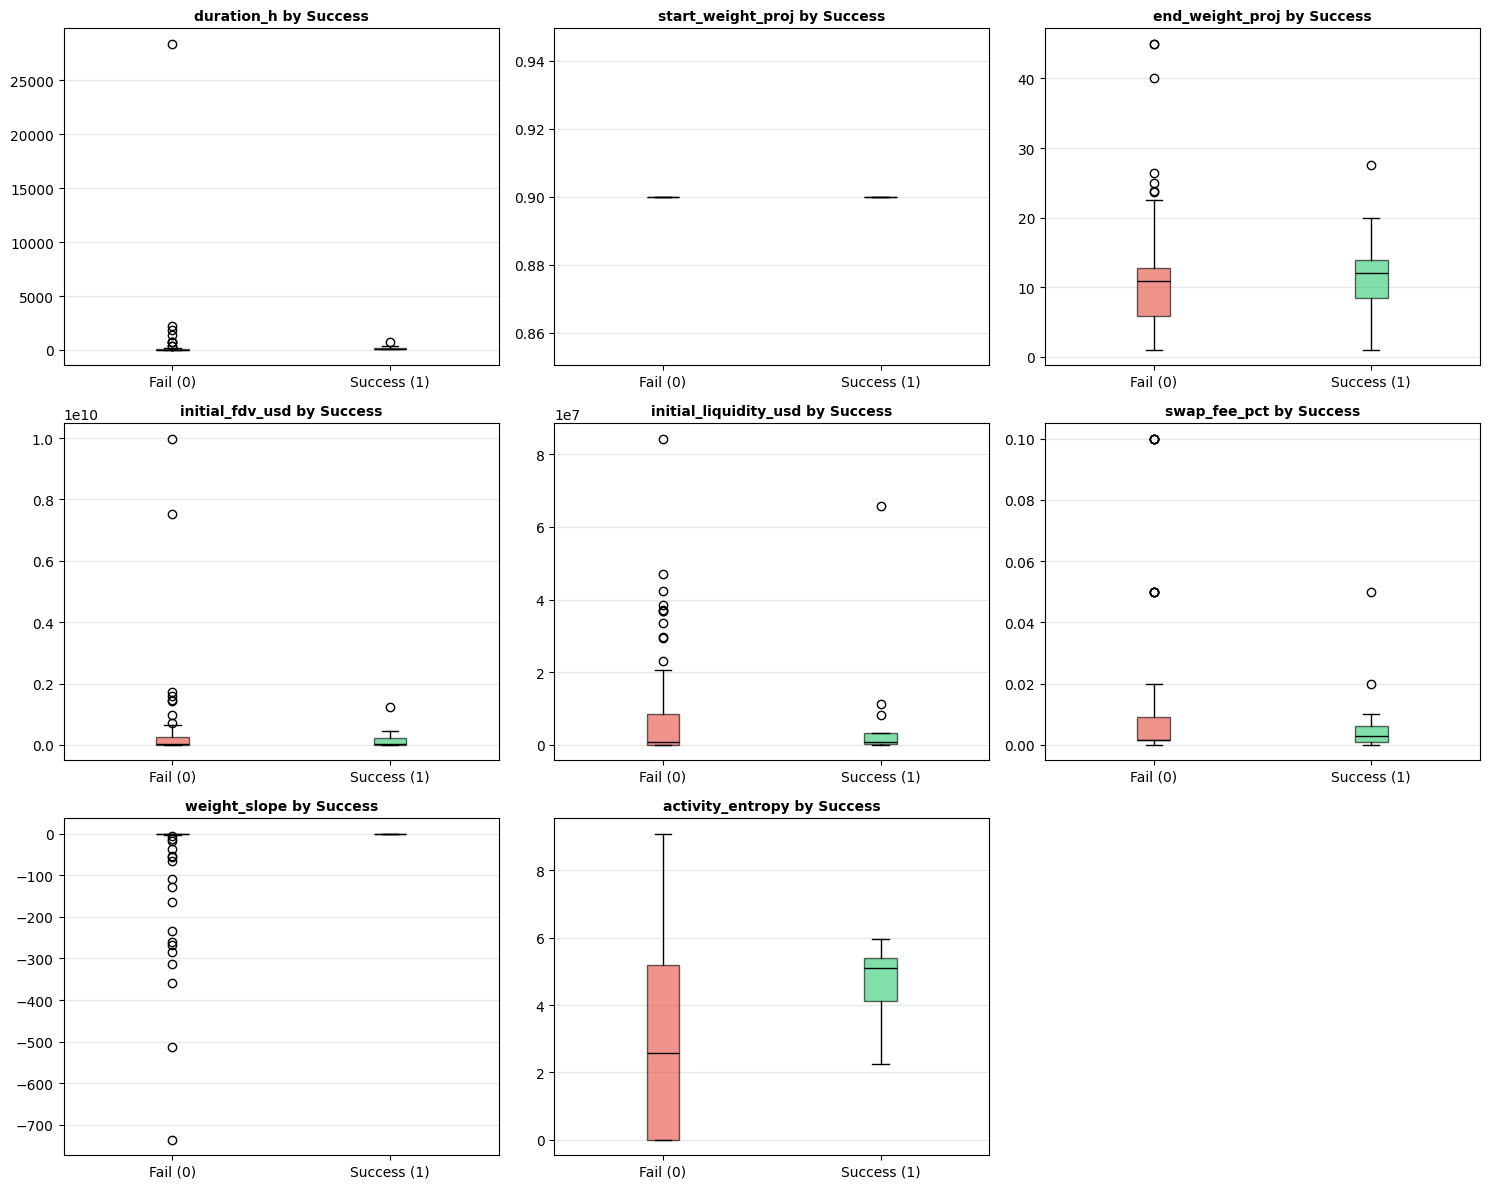

In [4]:
numerical_features = [
    'duration_h', 'start_weight_proj', 'end_weight_proj', 
    'initial_fdv_usd', 'initial_liquidity_usd', 'swap_fee_pct',
    'weight_slope', 'activity_entropy'
]


def plot_target_balance(df, target_col='final_success'):
    counts = df[target_col].value_counts()
    
    plt.figure(figsize=(6, 4))
    bars = plt.bar(counts.index.astype(str), counts.values, color=['#e74c3c', '#2ecc71'])
    
    plt.title(f'Target Distribution: {target_col}', fontsize=12)
    plt.ylabel('Count')
    plt.xlabel('Success (0 = Fail, 1 = Success)')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Add count labels on top
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()


def plot_numerical_distributions(df, features):
    n_cols = 3
    n_rows = math.ceil(len(features) / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(features):
        ax = axes[i]
        
        # Plot histogram
        ax.hist(df[col], bins=15, color='#3498db', edgecolor='black', alpha=0.7)
        
        # Add mean line
        mean_val = df[col].mean()
        ax.axvline(mean_val, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_val:.2f}')
        
        ax.set_title(f'Distribution: {col}', fontsize=10, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)

    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()


def plot_feature_vs_success(df, features, target='final_success'):
    n_cols = 3
    n_rows = math.ceil(len(features) / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(features):
        ax = axes[i]
        
        # Prepare data for boxplot
        data_0 = df[df[target] == 0][col]
        data_1 = df[df[target] == 1][col]
        
        # Create boxplot
        bp = ax.boxplot([data_0, data_1], labels=['Fail (0)', 'Success (1)'], 
                        patch_artist=True, medianprops=dict(color="black"))
        
        # Color coding
        colors = ['#e74c3c', '#2ecc71']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
            
        ax.set_title(f'{col} by Success', fontsize=10, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)

    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()


plt.style.use('fast') 

print("--- 1. Checking Class Balance ---")
plot_target_balance(v1_df)

print("--- 2. Checking Numerical Distributions ---")
plot_numerical_distributions(v1_df, numerical_features)

print("--- 3. Checking Feature Separation (Boxplots) ---")
plot_feature_vs_success(v1_df, numerical_features)

--- 1. Checking Correlations ---


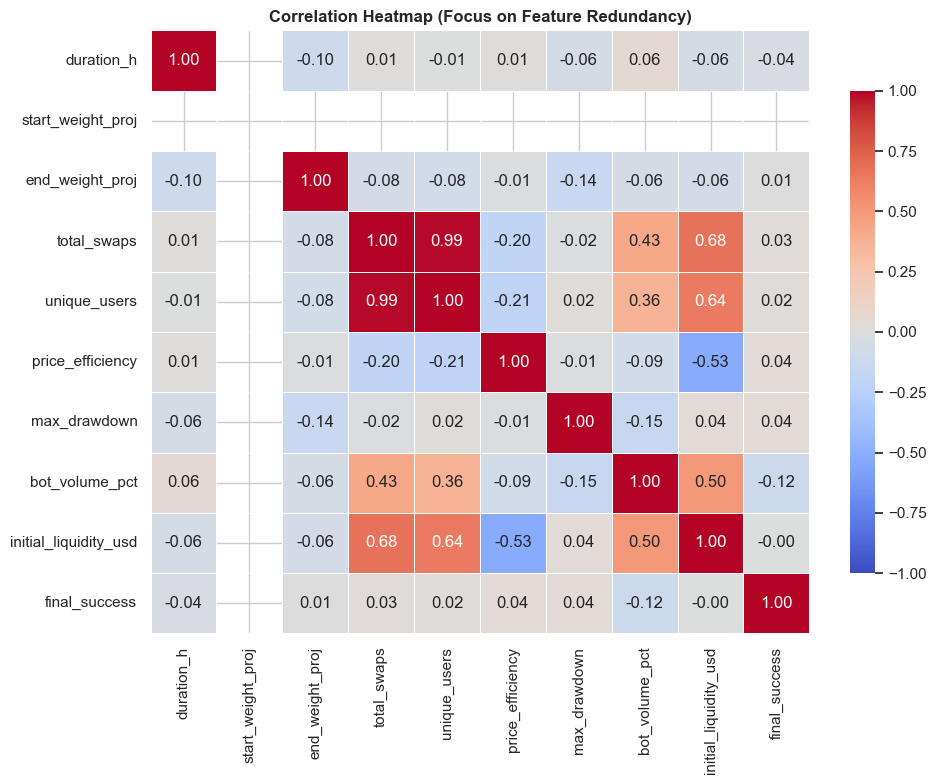

--- 2. Checking Bot Influence ---


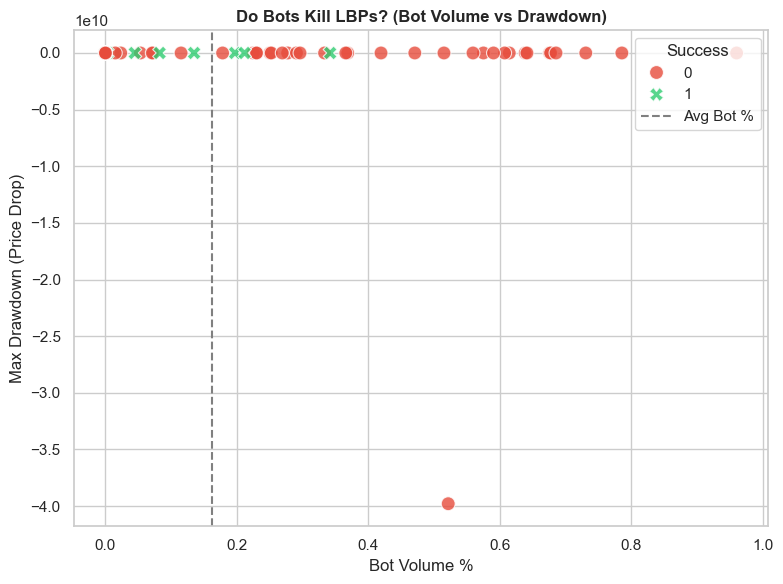

--- 3. Checking Build Parameters ---


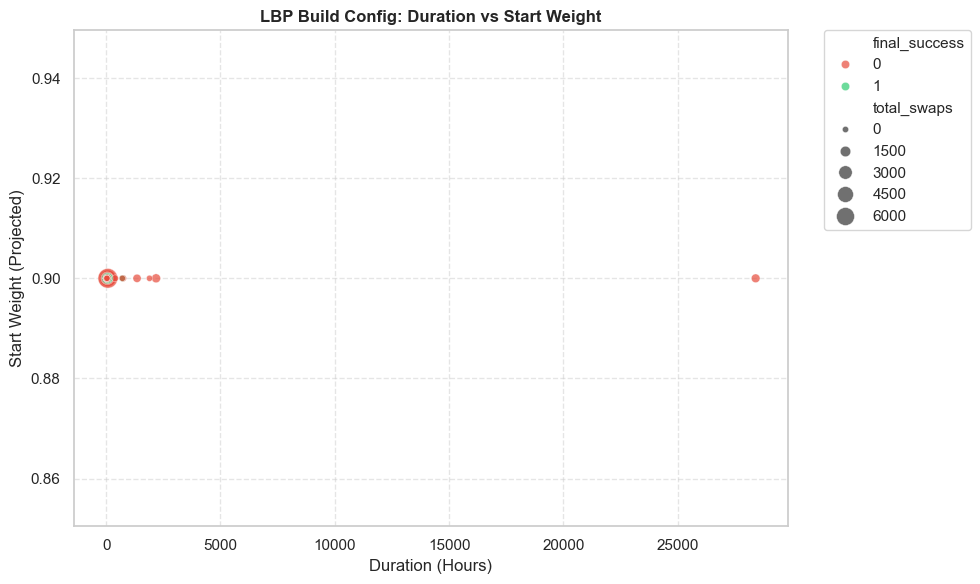

In [5]:
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. Correlation Matrix (to filter redundant features)
# ---------------------------------------------------------
def plot_correlation_matrix(df):
    # Select only numerical columns relevant to metrics
    cols_to_check = [
        'duration_h', 'start_weight_proj', 'end_weight_proj', 
        'total_swaps', 'unique_users', 'price_efficiency', 
        'max_drawdown', 'bot_volume_pct', 'initial_liquidity_usd',
        'final_success' # Important to see what correlates with target
    ]
    
    corr = df[cols_to_check].corr()

    plt.figure(figsize=(10, 8))
    # Heatmap with masking for the upper triangle (cleaner look)
    mask =  corr.where(abs(corr) > 0.3, 0) # Only show relevant correlations
    
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', 
                vmin=-1, vmax=1, center=0, linewidths=0.5,
                cbar_kws={"shrink": .8})
    
    plt.title('Correlation Heatmap (Focus on Feature Redundancy)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 2. Bot Impact Analysis (Scatter Plot)
# ---------------------------------------------------------
def plot_bot_impact(df):
    plt.figure(figsize=(8, 6))
    
    # Scatter: Bot Volume vs Max Drawdown, colored by Success
    sns.scatterplot(
        data=df, 
        x='bot_volume_pct', 
        y='max_drawdown', 
        hue='final_success', 
        style='final_success',
        palette={0: '#e74c3c', 1: '#2ecc71'},
        s=100, # dot size
        alpha=0.8
    )
    
    plt.title('Do Bots Kill LBPs? (Bot Volume vs Drawdown)', fontsize=12, fontweight='bold')
    plt.xlabel('Bot Volume %')
    plt.ylabel('Max Drawdown (Price Drop)')
    plt.axvline(x=df['bot_volume_pct'].mean(), color='gray', linestyle='--', label='Avg Bot %')
    plt.legend(title='Success', loc='upper right')
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 3. Configuration "Sweet Spot" (3D-like 2D plot)
# ---------------------------------------------------------
def plot_config_landscape(df):
    plt.figure(figsize=(10, 6))
    
    # We want to see: Duration vs Liquidity vs Success
    # Size of bubble = Total Volume (or Swaps) to show activity depth
    
    scatter = sns.scatterplot(
        data=df, 
        x='duration_h', 
        y='start_weight_proj', 
        hue='final_success',
        size='total_swaps', # Bubble size based on activity
        sizes=(20, 200),
        palette={0: '#e74c3c', 1: '#2ecc71'},
        alpha=0.7
    )
    
    plt.title('LBP Build Config: Duration vs Start Weight', fontsize=12, fontweight='bold')
    plt.xlabel('Duration (Hours)')
    plt.ylabel('Start Weight (Projected)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# Execution
# ---------------------------------------------------------
print("--- 1. Checking Correlations ---")
plot_correlation_matrix(v1_df)

print("--- 2. Checking Bot Influence ---")
plot_bot_impact(v1_df)

print("--- 3. Checking Build Parameters ---")
plot_config_landscape(v1_df)

In [21]:
import pandas as pd
import numpy as np

def calculate_weekend_pct(row):
    """
    Creates an hourly range from start to end and calculates 
    the ratio of hours that fall on Sat/Sun.
    """
    start = row['launch_date']
    duration = row['duration_h']
    
    if pd.isna(start) or pd.isna(duration) or duration <= 0:
        return 0.0
        
    # Create a frequency range of 1 Hour. 
    # ceil/floor logic isn't strictly necessary for approximation, just taking the range is fine.
    end = start + pd.Timedelta(hours=duration)
    
    # Generate hourly timestamps
    try:
        time_range = pd.date_range(start=start, end=end, freq='h')
    except:
        return 0.0 # Safety for bad dates
        
    if len(time_range) == 0:
        return 0.0
        
    # 5 = Saturday, 6 = Sunday
    weekend_hours = sum(1 for x in time_range if x.dayofweek >= 5)
    
    return weekend_hours / len(time_range)

def strict_clean_data(df):
    df_clean = df.copy()
    
    # --- 0. Feature Engineering: Weekend Percentage ---
    print("Generating 'weekend_pct' feature...")
    # Ensure launch_date is datetime
    df_clean['launch_date'] = pd.to_datetime(df_clean['launch_date'])
    # Apply the calculation
    df_clean['weekend_pct'] = df_clean.apply(calculate_weekend_pct, axis=1)
    
    # --- 1. Sanity Check (Physical Rules) ---
    rows_before = df_clean.shape[0] 
    
    # Duration must be positive
    df_clean = df_clean[df_clean['duration_h'] > 0]
    
    # FDV Logic: Flag and Fill (No dropping)
    df_clean['is_missing_fdv'] = np.where(df_clean['initial_fdv_usd'] <= 0, 1, 0)
    
    # Calculate median only from valid rows
    valid_fdv_subset = df_clean.loc[df_clean['initial_fdv_usd'] > 0, 'initial_fdv_usd']
    if not valid_fdv_subset.empty:
        valid_fdv_median = valid_fdv_subset.median()
    else:
        valid_fdv_median = 0 # Fallback if ALL are zero
        
    # Replace zero/negatives with median
    df_clean['initial_fdv_usd'] = df_clean['initial_fdv_usd'].apply(lambda x: valid_fdv_median if x <= 0 else x)

    print(f"Rows removed by Sanity Check: {rows_before - len(df_clean)}")

    # --- 2. Log Transforms ---
    # We filter the list to only include columns that actually exist in your DF
    potential_cols = ['initial_fdv_usd', 'initial_liquidity_usd', 'start_weight_proj']
    money_cols = [c for c in potential_cols if c in df_clean.columns]
    
    for col in money_cols:
        # Check for zeros before log to avoid -inf
        if (df_clean[col] <= 0).any():
             # Small clip to prevent crash, though logic above should handle FDV
             df_clean[col] = df_clean[col].clip(lower=1e-9) 
        df_clean[f'log_{col}'] = np.log1p(df_clean[col])

    # --- 3. Statistical Cleaning (IQR) ---
    # Usually strictly bounded 0-1, so checking outliers isn't strictly necessary but safe.
    cols_to_filter = ['duration_h', 'weight_slope', 'max_drawdown', 'bot_volume_pct']
    
    # Only filter columns that exist
    cols_to_filter = [c for c in cols_to_filter if c in df_clean.columns]
    
    threshold = 4.5 
    indices_to_drop = set()
    
    print(f"\n--- Statistical Cleaning (Threshold: {threshold}) ---")
    for col in cols_to_filter:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # If IQR is 0 (e.g., column is constant), skip filtering to avoid deleting everything
        if IQR == 0:
            continue
            
        lower_bound = Q1 - (threshold * IQR)
        upper_bound = Q3 + (threshold * IQR)
        
        # Logical Bounds
        if col == 'duration_h': lower_bound = max(lower_bound, 0)
        
        outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
        
        if len(outliers) > 0:
            print(f"Column '{col}': Found {len(outliers)} outliers (Range: {lower_bound:.2f} to {upper_bound:.2f})")
            indices_to_drop.update(outliers.index)
            
    df_final = df_clean.drop(index=list(indices_to_drop))
    
    print("-" * 40)
    print(f"Original Rows: {len(df)}")
    print(f"Final Rows:    {len(df_final)}")
    print("-" * 40)
    
    return df_final

# Usage
v1_df_ready = strict_clean_data(v1_df)

Generating 'weekend_pct' feature...
Rows removed by Sanity Check: 0

--- Statistical Cleaning (Threshold: 4.5) ---
Column 'duration_h': Found 9 outliers (Range: 0.00 to 360.28)
Column 'weight_slope': Found 18 outliers (Range: -5.08 to 4.01)
Column 'max_drawdown': Found 13 outliers (Range: -84.10 to 68.81)
----------------------------------------
Original Rows: 96
Final Rows:    59
----------------------------------------


## Recreate analysis after data cleaning

--- 1. Checking Class Balance ---


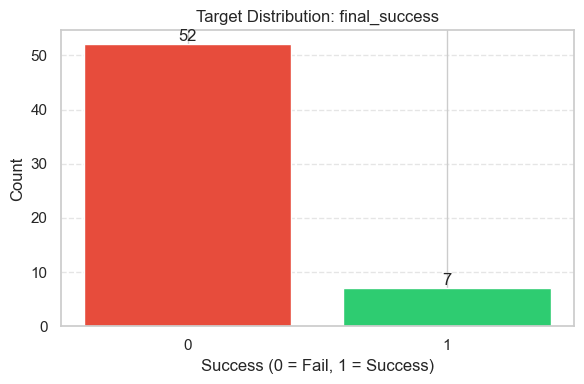

--- 2. Checking Numerical Distributions ---


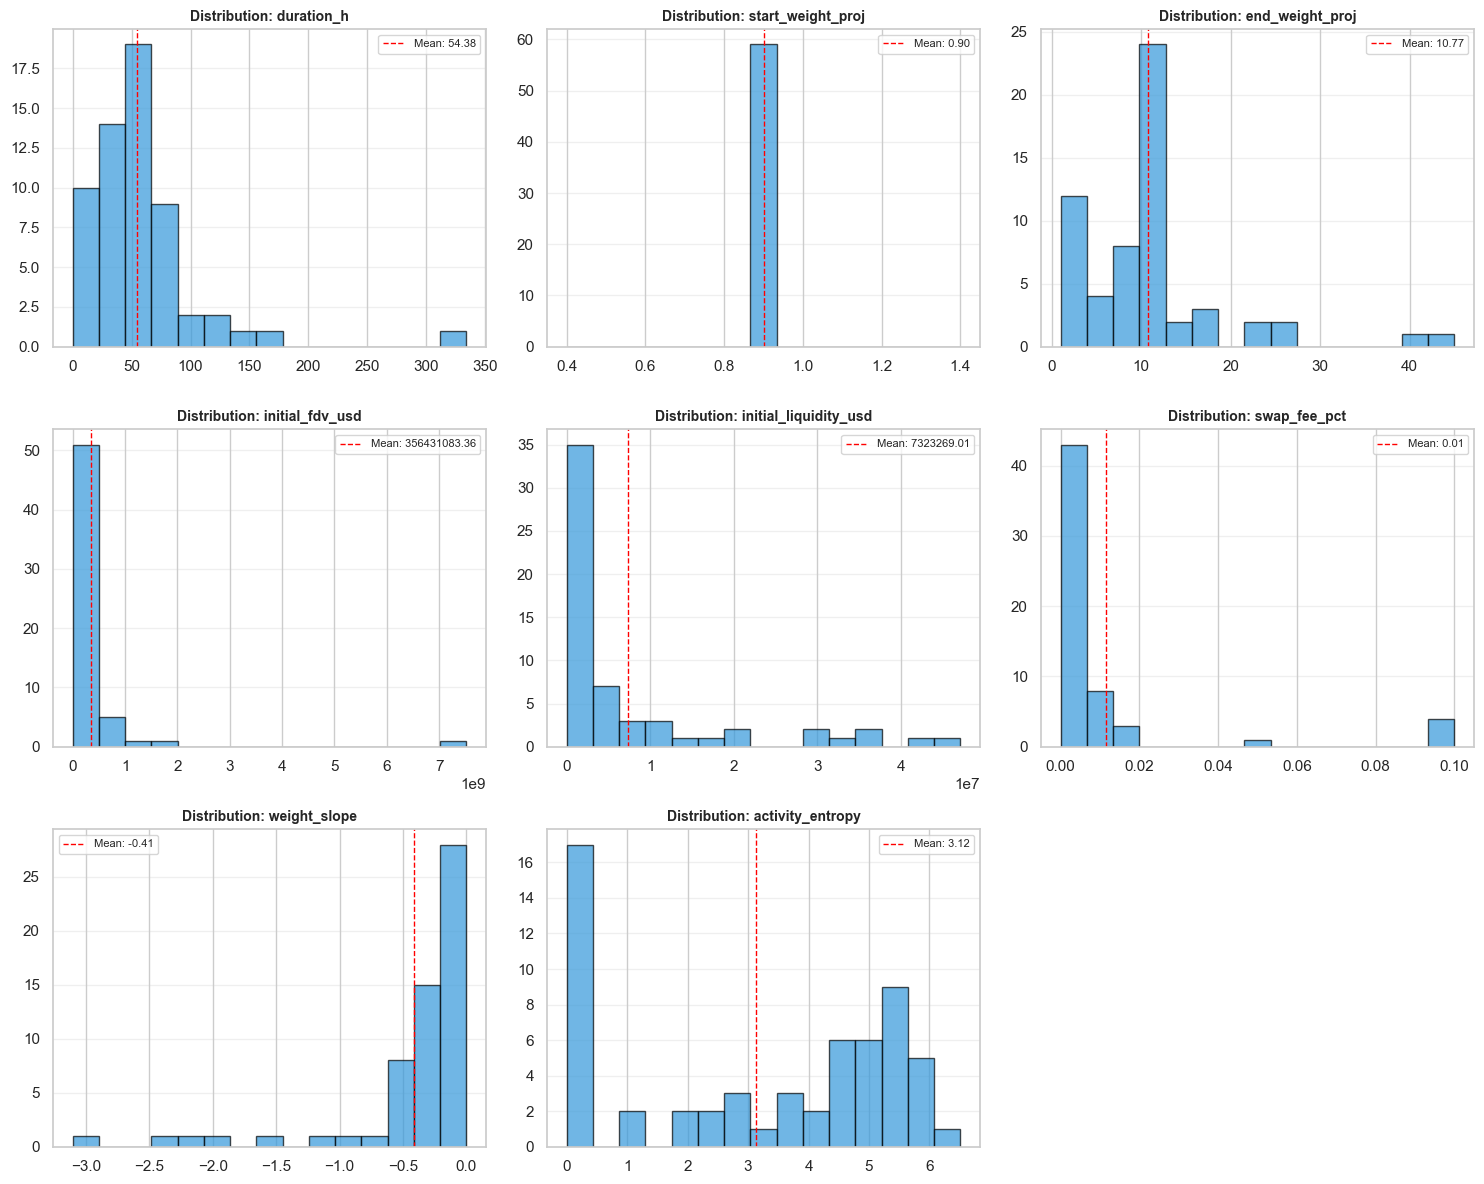

--- 3. Checking Feature Separation (Boxplots) ---


C:\Users\kaiqu\AppData\Local\Temp\ipykernel_21668\3008103398.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1], labels=['Fail (0)', 'Success (1)'],
C:\Users\kaiqu\AppData\Local\Temp\ipykernel_21668\3008103398.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1], labels=['Fail (0)', 'Success (1)'],
C:\Users\kaiqu\AppData\Local\Temp\ipykernel_21668\3008103398.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1], labels=['Fail (0)', 'Success (1)'],
C:\Users\kaiqu\AppData\Local\Temp\ipykernel_21668\3008103398.py:73: Matpl

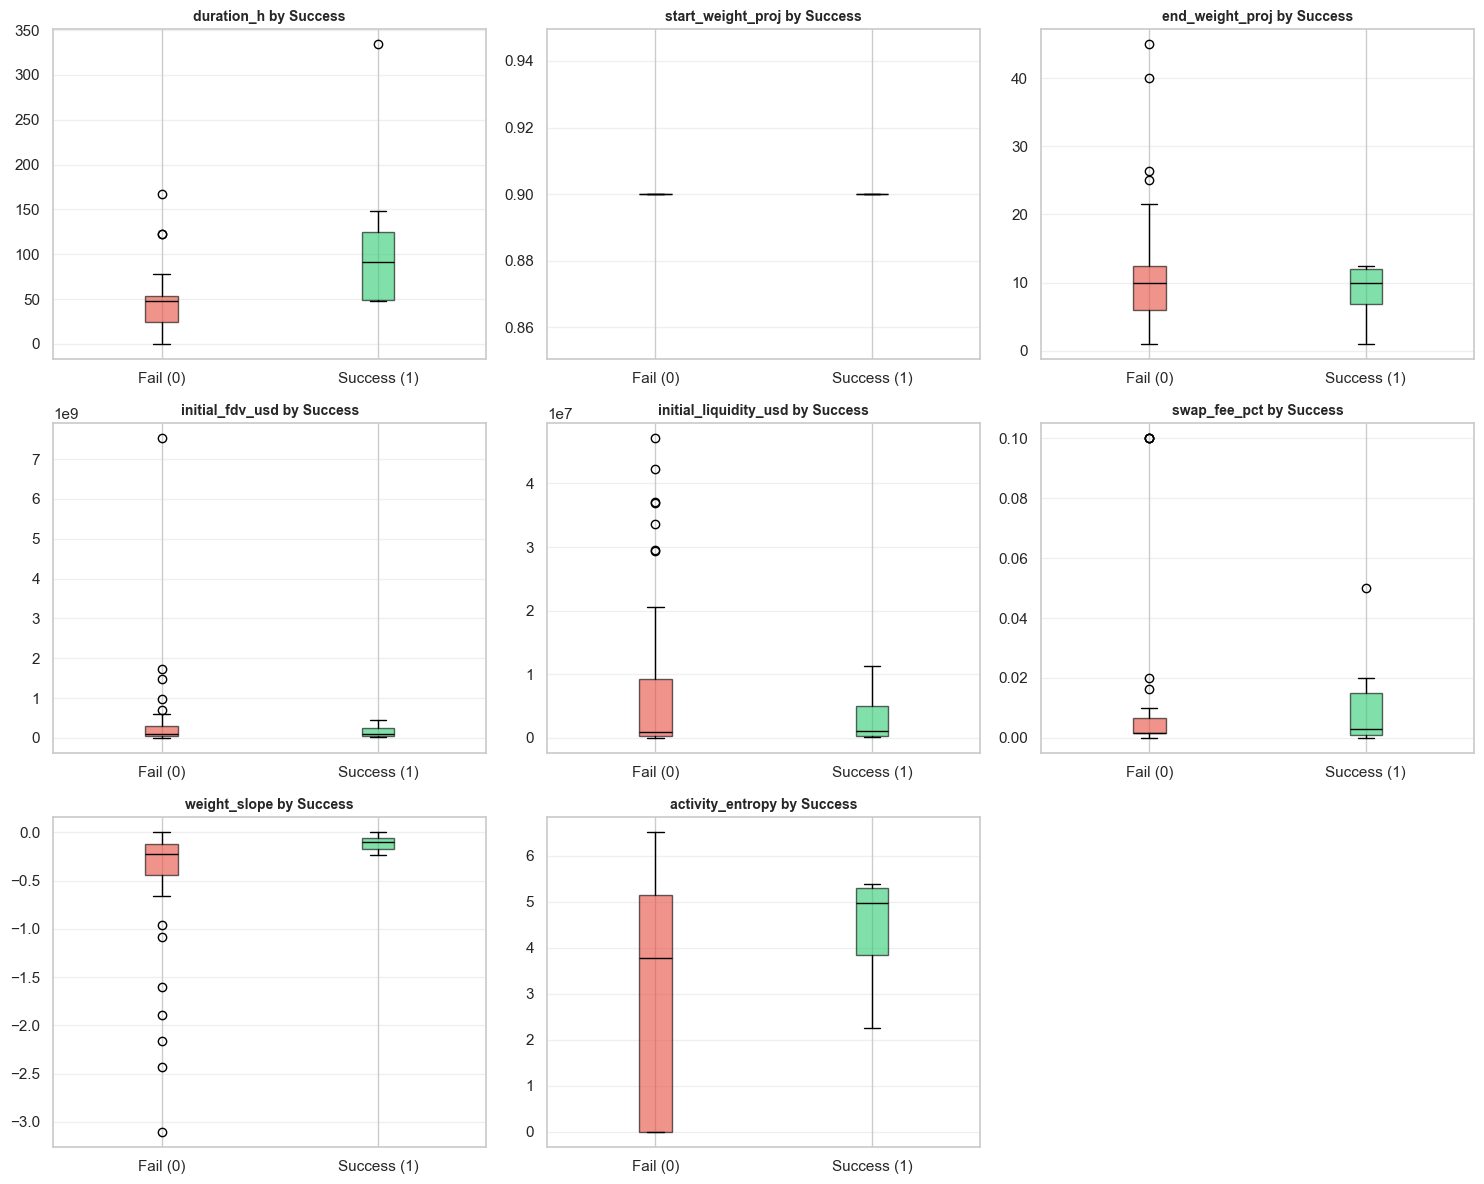

In [22]:
print("--- 1. Checking Class Balance ---")
plot_target_balance(v1_df_ready)

print("--- 2. Checking Numerical Distributions ---")
plot_numerical_distributions(v1_df_ready, numerical_features)

print("--- 3. Checking Feature Separation (Boxplots) ---")
plot_feature_vs_success(v1_df_ready, numerical_features)

--- 1. Checking Correlations ---


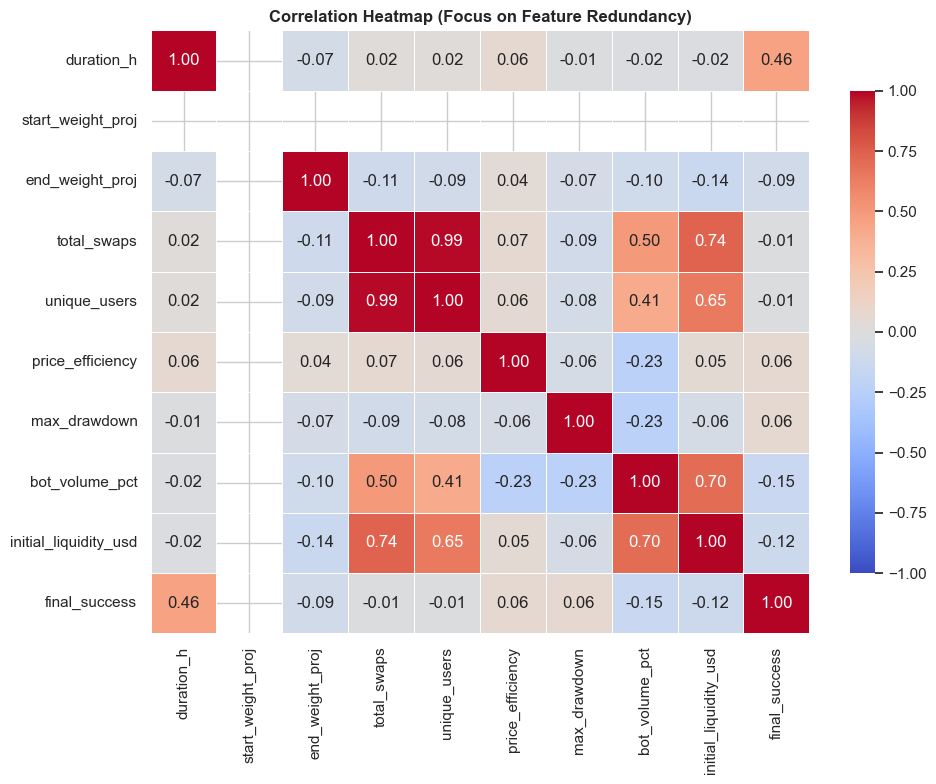

--- 2. Checking Bot Influence ---


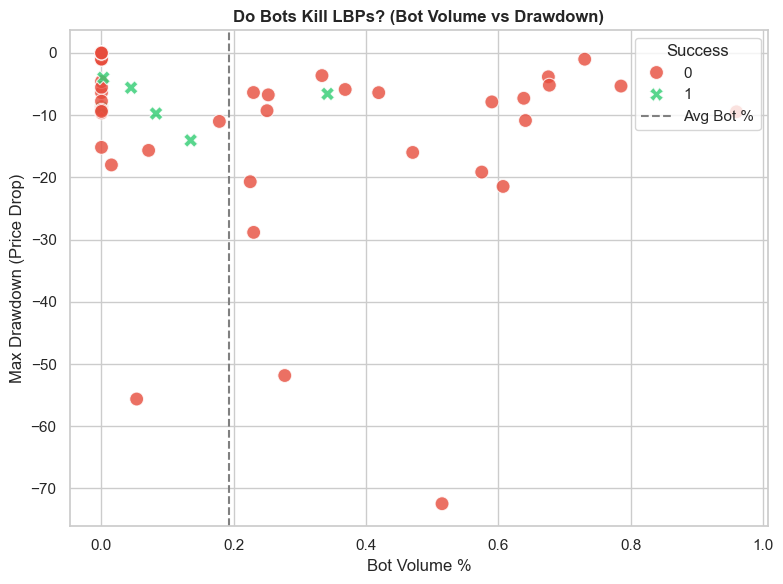

--- 3. Checking Build Parameters ---


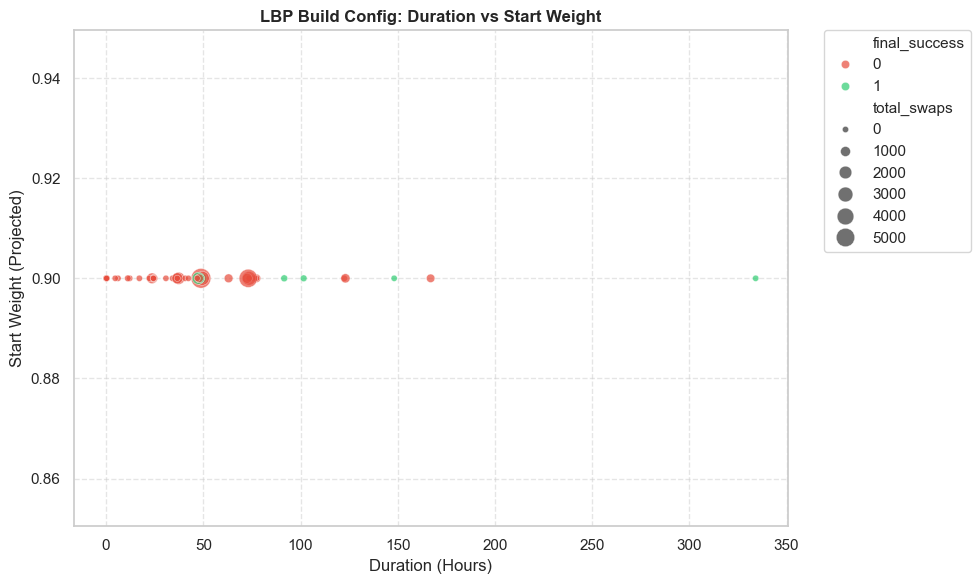

In [23]:
print("--- 1. Checking Correlations ---")
plot_correlation_matrix(v1_df_ready)

print("--- 2. Checking Bot Influence ---")
plot_bot_impact(v1_df_ready)

print("--- 3. Checking Build Parameters ---")
plot_config_landscape(v1_df_ready)

## Prepare dataset to ML training

In [26]:
# 1. Define your Input Features (X) - The 10 columns for the model
feature_cols = [
    'duration_h', 
    'start_weight_proj', 
    'end_weight_proj', 
    'weight_slope', 
    'initial_fdv_usd',
    'is_missing_fdv',
    # 'initial_liquidity_usd', 
    'swap_fee_pct', 
    'collateral_is_stable', 
    'is_weekend', 
    'hour_of_day',
    'weekend_pct'
]

# 2. Define your Output Targets (y) - What you want to predict
target_cols = [
    'price_found_success', 
    'consistent_activity_success', 
    'not_bot_success', 
    'final_success'
]

# 3. Create the dedicated ML dataframe
v1_df_ml = v1_df_ready[feature_cols + target_cols].copy()

# 4. Final verification
print(f"Final ML Dataset Shape: {v1_df_ml.shape}")
print("-" * 30)
print("Input Features:", len(feature_cols))
print("Output Targets:", len(target_cols))
print("-" * 30)

# 5. Save to a new CSV file
v1_df_ml.to_csv('balancer_v1_ml_training_data.csv', index=False)

print("Success! File 'balancer_v1_ml_training_data.csv' created.")
v1_df_ml

Final ML Dataset Shape: (59, 15)
------------------------------
Input Features: 11
Output Targets: 4
------------------------------
Success! File 'balancer_v1_ml_training_data.csv' created.


,duration_h,start_weight_proj,end_weight_proj,weight_slope,initial_fdv_usd,is_missing_fdv,swap_fee_pct,collateral_is_stable,is_weekend,hour_of_day,weekend_pct,price_found_success,consistent_activity_success,not_bot_success,final_success
0,34.146667,0.9,2.392344,-0.043704,9.461676e+07,1,0.001500,1,0,10,0.000000,0,0,1,0
1,0.041111,0.9,1.000000,-2.432432,7.004722e+08,0,0.006900,0,1,18,1.000000,0,0,1,0
2,74.664444,0.9,17.500000,-0.222328,1.024989e+07,0,0.001500,0,0,13,0.000000,0,1,1,0
3,23.631111,0.9,11.250000,-0.437982,1.613912e+08,0,0.005000,1,0,12,0.000000,0,1,1,0
5,77.347500,0.9,12.500000,-0.149973,9.623615e+08,0,0.001500,1,0,13,0.551282,1,1,0,0
6,77.374444,0.9,12.500000,-0.149920,9.461676e+07,0,0.001500,0,0,9,0.000000,0,0,1,0
8,12.140833,0.9,12.500000,-0.955453,1.772398e+08,0,0.001500,1,0,0,0.000000,0,0,1,0
10,73.893611,0.9,1.000000,-0.001353,3.861751e+02,0,0.001500,0,1,10,0.513514,0,1,1,0
12,122.531667,0.9,8.000000,-0.057944,5.626414e+05,0,0.000400,1,0,17,0.390244,0,1,1,0
15,24.813889,0.9,6.250000,-0.215605,9.461676e+07,0,0.100000,0,0,14,0.000000,0,1,1,0


# V2

In [34]:
v2_df = pd.read_csv('../media/v2/FINAL_LBPs_BalancerV2.csv')
v2_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426 entries, 0 to 425
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   pool_id                      426 non-null    object 
 1   launch_date                  426 non-null    object 
 2   duration_h                   426 non-null    float64
 3   start_weight_proj            426 non-null    float64
 4   end_weight_proj              426 non-null    float64
 5   total_swaps                  426 non-null    int64  
 6   unique_users                 426 non-null    int64  
 7   swaps_per_hour               426 non-null    float64
 8   activity_entropy             426 non-null    float64
 9   max_drawdown                 426 non-null    float64
 10  price_efficiency             426 non-null    float64
 11  bot_volume_pct               426 non-null    float64
 12  initial_fdv_usd              426 non-null    float64
 13  buy_pressure_avg    

## Data distribution and cleaning

--- 1. Checking Class Balance ---


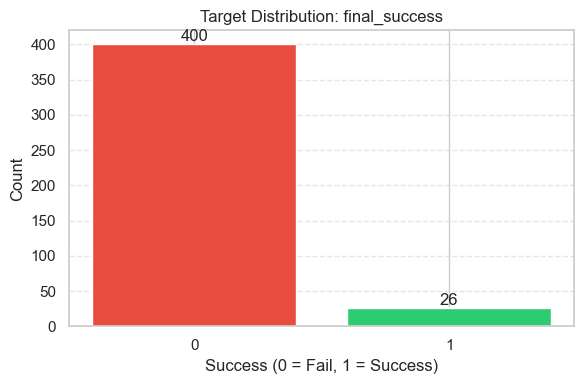

--- 2. Checking Numerical Distributions ---


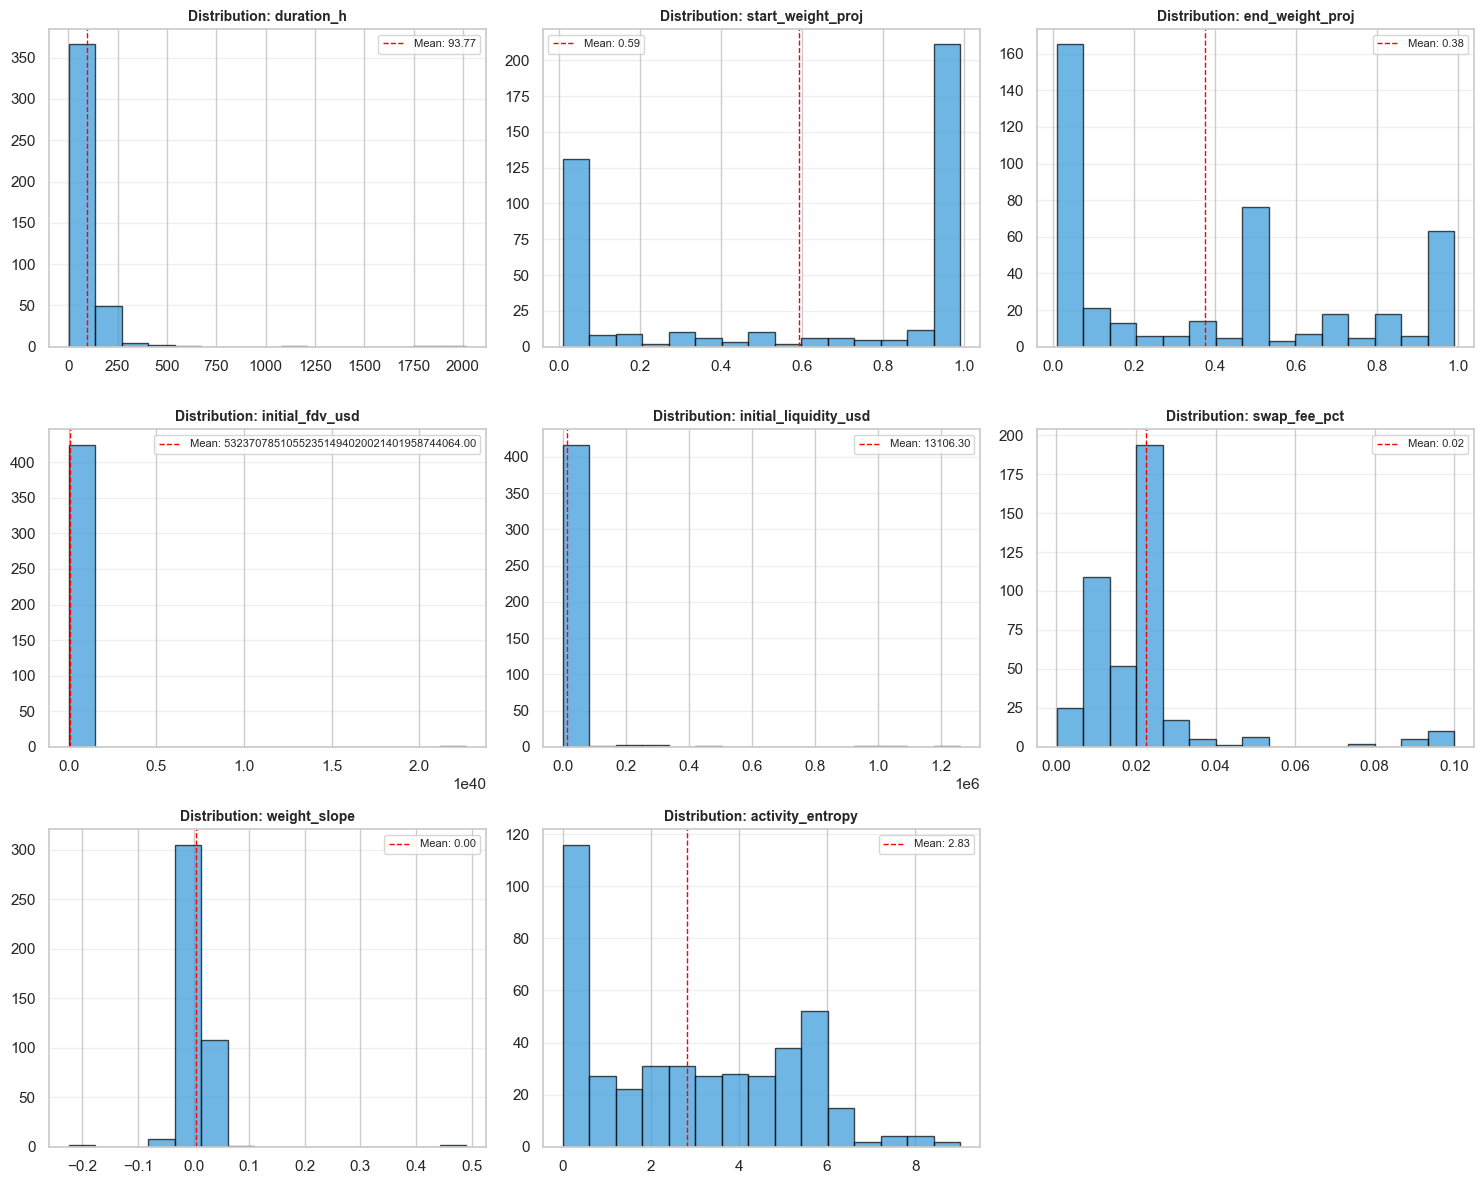

--- 3. Checking Feature Separation (Boxplots) ---


C:\Users\kaiqu\AppData\Local\Temp\ipykernel_21668\3008103398.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1], labels=['Fail (0)', 'Success (1)'],
C:\Users\kaiqu\AppData\Local\Temp\ipykernel_21668\3008103398.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1], labels=['Fail (0)', 'Success (1)'],
C:\Users\kaiqu\AppData\Local\Temp\ipykernel_21668\3008103398.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1], labels=['Fail (0)', 'Success (1)'],
C:\Users\kaiqu\AppData\Local\Temp\ipykernel_21668\3008103398.py:73: Matpl

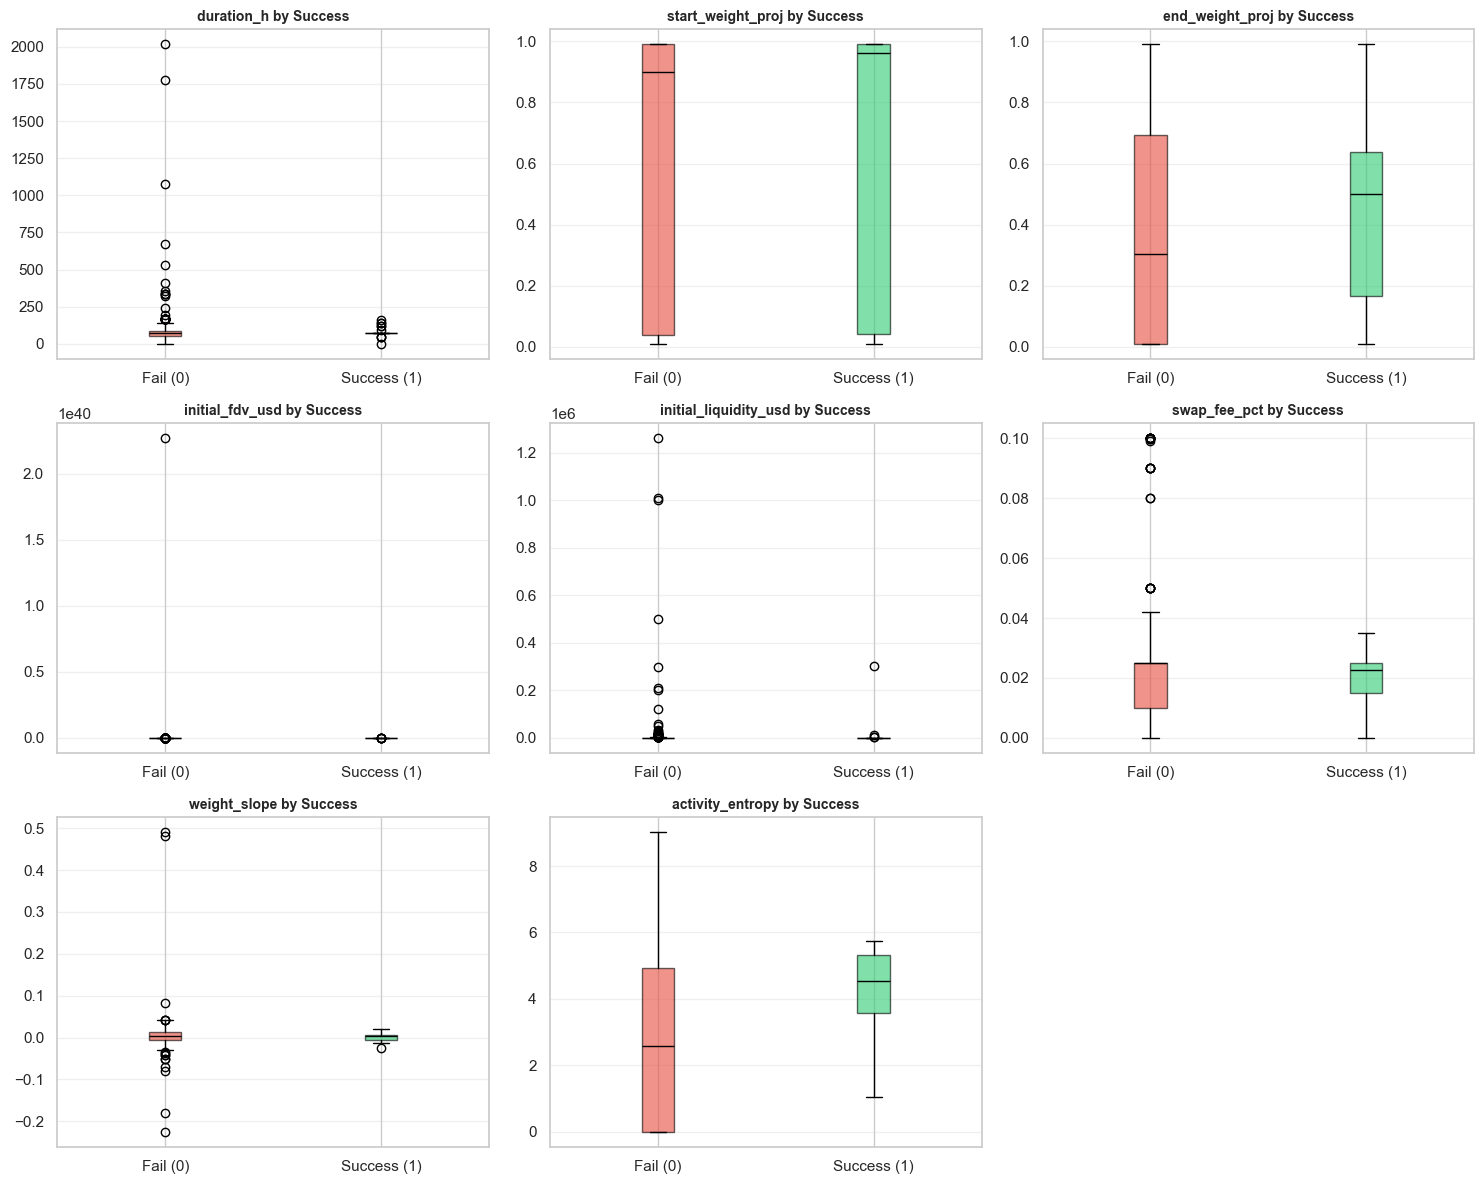

In [30]:
print("--- 1. Checking Class Balance ---")
plot_target_balance(v2_df)

print("--- 2. Checking Numerical Distributions ---")
plot_numerical_distributions(v2_df, numerical_features)

print("--- 3. Checking Feature Separation (Boxplots) ---")
plot_feature_vs_success(v2_df, numerical_features)

--- 1. Checking Correlations ---


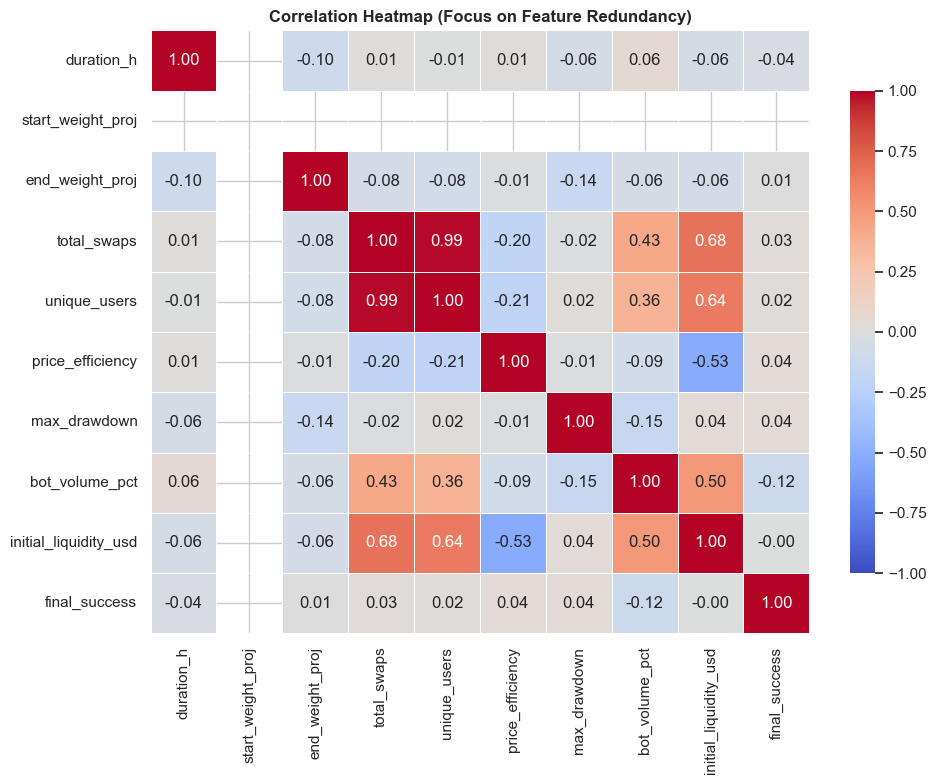

--- 2. Checking Bot Influence ---


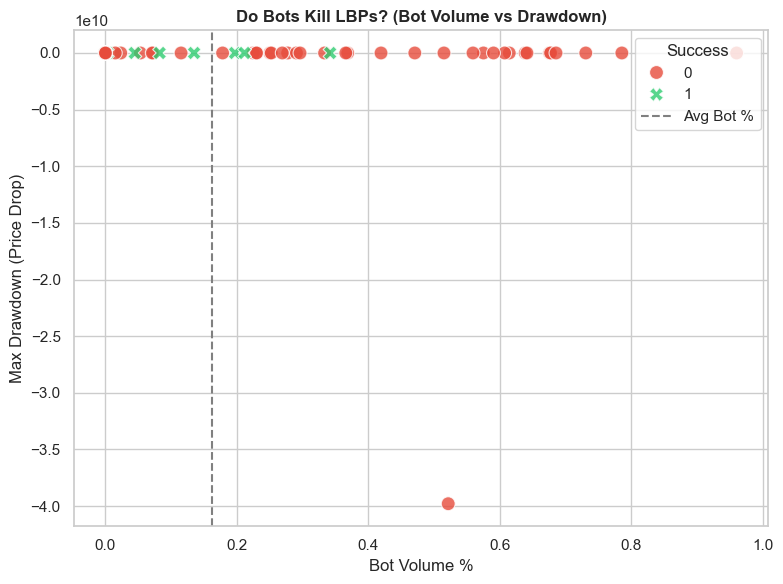

--- 3. Checking Build Parameters ---


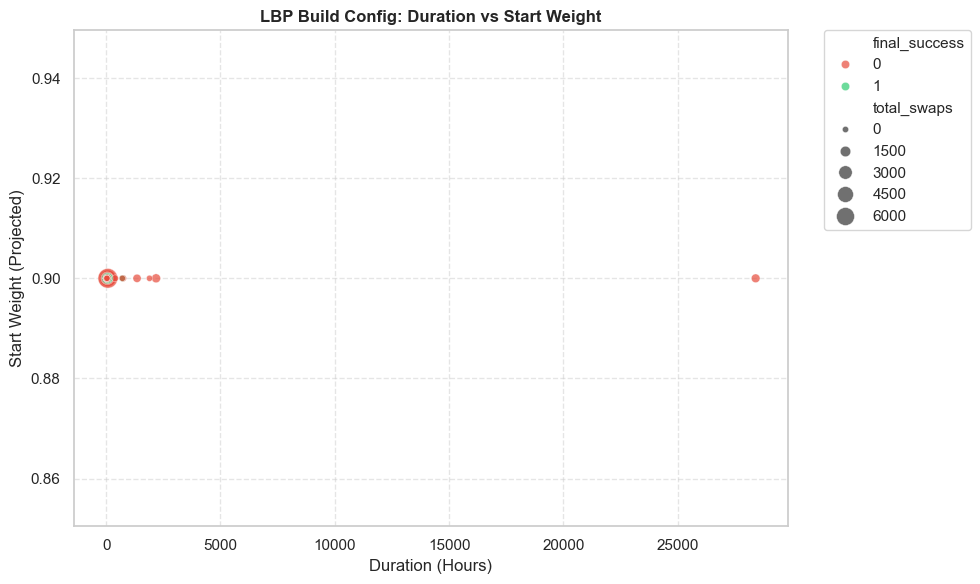

In [31]:
print("--- 1. Checking Correlations ---")
plot_correlation_matrix(v1_df)

print("--- 2. Checking Bot Influence ---")
plot_bot_impact(v1_df)

print("--- 3. Checking Build Parameters ---")
plot_config_landscape(v1_df)

In [46]:
# Create a filter for the "bad" liquidity rows
bad_data = v2_df[v2_df['initial_liquidity_usd'] <= 0]

print("--- Inspecting Negative Data ---")
print(bad_data[['pool_id', 'initial_liquidity_usd', 'initial_fdv_usd']].head(10))

print("\n--- Value Analysis ---")
print("Count of exactly -1:", len(bad_data[bad_data['initial_liquidity_usd'] == -1]))
print("Count of exactly  0:", len(bad_data[bad_data['initial_liquidity_usd'] == 0]))
print("Smallest negative value:", bad_data['initial_liquidity_usd'].min())

--- Inspecting Negative Data ---
                                              pool_id  initial_liquidity_usd  \
0   0xb37a8e9ceafa4a3636d6bcdb35ee1e94c20c78e00002...                    0.0   
1   0x0f22556c1035337391a5b0664190c6b8327327280002...                    0.0   
2   0x11cc00181680ffad62cce2771154a77e4c2a73cf0002...                    0.0   
4   0x94ce642f78ef731a3748dd058c084458af1b56300002...                    0.0   
6   0x8a97d99c58db4aee085de188983388b79ca7d9f00002...                    0.0   
11  0x40f1cb91325dd8ef24dfac085c9ba46ea309e5e20002...                    0.0   
13  0x7e8fd1b4dbdfedb682c23ec79618f6cb0d68d3360002...                    0.0   
14  0x753bd6a5bf0b14ae7e5d2877e5cd6a3398aa2aab0002...                    0.0   
20  0x0a336d1a947dc92855a228f653f71f6905729b270002...                    0.0   
21  0x80ba1773e82070c284907eaee2ba05453f14f0710002...                    0.0   

    initial_fdv_usd  
0      0.000000e+00  
1      0.000000e+00  
2      5.918544e+11 

In [35]:
v2_df_ready = strict_clean_data(v2_df)

Generating 'weekend_pct' feature...
Rows removed by Sanity Check: 0

--- Statistical Cleaning (Threshold: 4.5) ---
Column 'duration_h': Found 12 outliers (Range: 0.00 to 237.38)
Column 'weight_slope': Found 4 outliers (Range: -0.09 to 0.10)
Column 'bot_volume_pct': Found 74 outliers (Range: -6.29 to 7.69)
----------------------------------------
Original Rows: 426
Final Rows:    342
----------------------------------------


In [36]:
v2_df_ml = v2_df_ready[feature_cols + target_cols].copy()

# 4. Final verification
print(f"Final ML Dataset Shape: {v2_df_ml.shape}")
print("-" * 30)
print("Input Features:", len(feature_cols))
print("Output Targets:", len(target_cols))
print("-" * 30)

# 5. Save to a new CSV file
v2_df_ml.to_csv('balancer_v2_ml_training_data.csv', index=False)

print("Success! File 'balancer_v2_ml_training_data.csv' created.")
v2_df_ml

Final ML Dataset Shape: (342, 15)
------------------------------
Input Features: 11
Output Targets: 4
------------------------------
Success! File 'balancer_v2_ml_training_data.csv' created.


,duration_h,start_weight_proj,end_weight_proj,weight_slope,initial_fdv_usd,is_missing_fdv,swap_fee_pct,collateral_is_stable,is_weekend,hour_of_day,weekend_pct,price_found_success,consistent_activity_success,not_bot_success,final_success
0,168.0,0.010010,0.99,-0.005833,9.182825e+06,1,0.010000,0,0,15,0.284024,0,0,1,0
1,24.0,0.990005,0.01,0.040834,9.182825e+06,1,0.010000,0,0,7,0.320000,0,0,1,0
3,72.0,0.050004,0.80,-0.010417,5.437746e+11,0,0.010000,1,1,2,0.301370,0,1,1,0
4,40.0,0.900008,0.50,0.010000,4.761107e+01,0,0.010000,1,1,10,0.926829,0,0,1,0
6,37.0,0.950011,0.20,0.020271,9.185174e+08,0,0.010000,0,0,2,0.000000,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,23.0,0.970001,0.25,0.031304,9.182825e+06,1,0.010000,0,0,16,0.000000,1,1,0,0
416,81.0,0.060014,0.42,-0.004444,6.935281e+12,0,0.015000,1,1,14,0.414634,1,1,0,0
420,72.0,0.040009,0.51,-0.006528,9.182825e+06,1,0.000026,0,0,22,0.000000,1,1,1,1
424,11.0,0.960006,0.04,0.083637,1.843408e+07,0,0.010000,0,1,0,1.000000,0,0,1,0
